In [1]:
from qiskit.circuit import QuantumCircuit, QuantumRegister, AncillaRegister
from qiskit.quantum_info import Statevector, Operator
from qiskit import *

import matplotlib.pyplot as plt

import numpy as np

# QC III: Quantum Fourier Transform and Phase estimation


It is not entirely unaccurate to suggest that the quantum Fourier transform is the single most important "algorithm" to quantum computing. 
At the current state of the art, most non-trivial quantum algorithms will either use Grover's algorithm of QFT "under the hood" to do the
"quantum heavy lifting" -- the rest of the non-trivial matters are usually a matter of classical computation or processing.


While the quantum Fourier transform is of theoretical importance, it can be implemented efficiently -- requiring only $\mathcal{O}(n^{2})$ many gates, 
and can be implemented with some basic quantum gates. The quantum Fourier transform. Similar to how Grover's algorithm was quite a general description of
how you might utilize amplitude amplification for the sake of a search problem, QFT is also more like a broad idea or "technique" that you might use to
solve a more specific type of problem. We will see that some examples of important applications of the QFT "technique" will be 

1. Implementing arithemtic efficiently with quantum circuits

2. Quantum Phase estimation

3. Shor's algorithm



As important as the quantum Fourier transform is, the idea is actually quite simple. Recall that the discrete Fourier transform (DFT) is a general procedure that one can do on the finite dimensional vector space $\mathbb{C}^{N}$ -- one just has to realize that the DFT is in fact a *unitary transformation*. Thus, it is a valid "quantum transformation" that one can apply to a quantum system. Therefore, from a mathematical point of view, the "QFT" is simply just applying the DFT from linear algebra to a finite-dimensional Hilbert space associated to an $n$-qubit system $\mathcal{H}(n)$. The less trivial content involved with the quantum Fourier transform and applying DFT to $\mathcal{H}(n)$ is knowing that the QFT can be effectively realized with a quadratic number of Pauli gates. 


### <u> A quick review of the discrete Fourier transform </U>



<ins>Input:</ins>  Given a function $f : \mathbb{Z}_{N} \rightarrow \mathbb{C}$ 

<ins>Output:</ins> The discrete Fourier transform of $f$ is the function $\mathcal{F}(f)(z) =  \frac{1}{\sqrt{N}} \sum\limits_{x = 0}^{N-1} e^{\frac{2 \pi i ( x \cdot z)  }{N} } f(x) $

<b> Properties of $\mathcal{F}(-)$: </b>

1. $\mathcal{F}$ is a linear map on the space of functions $f: \mathbb{Z}_{N} \rightarrow \mathbb{C}$   ($\cong \mathbb{C}^{N}$)
2. By Parseval's theorem, $\mathcal{F}$ is in fact a unitary map.
3.  For $k \in \mathbb{Z}$, define $T_{k}(f)(x) = f \big(  (x - k) \textnormal{ \tiny  mod N }  \big)$. Then one has 

$$
( \mathcal{F}^{-1} \circ T_{k} \circ \mathcal{F} )(f)(x) = e^{  \frac{2 \pi i( k x ) }{N}} f(x)
$$

<!-- The first two properties means that we can implement this with qubits -- that is, there should be a quantum gate implementation of $\mathcal{F}$ as a map on $\mathcal{C}^{N}$ where $N = 2^{n}$ for some $n$.  -->
The third property essentially says that the DFT transforms "shifts in function argument to shifts in phase".



-------------------------------------------


With the discrete Fourier transform at our disposal, the QFT is the unitary transformation acting on $\mathcal{H}(n)$ in the following way: 
for $\ket{\psi} = \sum\limits_{x \in \mathbb{F}_{2}^{n}} \psi_{x} \ket{x}$, we define

$$
\text{QFT} \ket{\psi} = \frac{1}{\sqrt{2^{n}}} \Big( \sum\limits_{z = 0}^{2^{n} - 1 } \sum\limits_{x = 0}^{2^{n} - 1 }  e^{\frac{2 \pi i }{ 2^{n} } x \cdot z } \psi_{x} \ket{z}   \Big)
$$

Or simpler, if we describe the action of QFT on the computational basis states, QFT is determined by 

$$
\text{QFT} \ket{x} = \frac{1}{\sqrt{2^{n}}} \Big( \sum\limits_{z = 0 }^{2^{n} - 1}  e^{ \frac{2 \pi i}{2^{n}}  x \cdot z  } \ket{z}  \Big)
$$


We can readily compute the inverse transformation to be

$$
\text{QFT}^{\dagger} \ket{x} = \frac{1}{\sqrt{ 2^{n} }} \Big(  \sum\limits_{z = 0 }^{2^{n} - 1}  e^{ - \frac{2 \pi i}{2^{n}}  x \cdot z  } \ket{z} \Big)
$$

------------------------------------------------

Let's assume for now that we can effectively construct a quantum gate corresponding to QFT, and take a look at an interesting application of the QFT transformation.


### Draper's adder circuit

Suppose that $k \in \mathbb{Z}$. Draper's adder circuit implements the unitary transformation that acts on the computational basis elements as follows

$$
A_{k} \ket{x}_{n}  = \ket{ x + k \text{ (mod } 2^{n}) }_{n}
$$


The idea is here that this transformation is easier to describe and implement in the "Fourier space". Note that 

$$
A_{k} \text{QFT}^{\dagger} \ket{x} = \frac{1}{\sqrt{ 2^{n} }} \Big(  \sum\limits_{z = 0 }^{2^{n} - 1}  e^{ - \frac{2 \pi i}{2^{n}}  x \cdot z  } A_{k} \ket{z} \Big)
$$

$$
= \frac{1}{\sqrt{ 2^{n} }} \Big(\sum\limits_{z = 0 }^{2^{n} - 1}  e^{ - \frac{2 \pi i}{2^{n}}  x \cdot ( z + k)   + \frac{ 2 \pi i }{2^{n}}( x \cdot k )  } \Big) \ket{ z + k } 
$$

$$
= e^{\frac{2 \pi i }{2^{n}} x \cdot k } \text{QFT}^{\dagger} \ket{x} 
$$

Therefore, conjugating $A_{k}$ by $\text{QFT}$ gives

$$
\text{QFT} \circ A_{k} \circ \text{QFT}^{\dagger} \ket{x} = e^{\frac{2 \pi i }{2^{n}} x \cdot k } \ket{x}
$$

Therefore, we can write $A_{k}$ as 

$$
A_{k} \ket{x} = \text{QFT} \big(     e^{\frac{2 \pi i }{2^{n}} x \cdot k } \text{QFT}^{\dagger} \ket{x}    \big)
$$

So, if we can implement $\text{QFT}$ easily, then we can implement $A_{k}$ easily as a quantum circuit. 

--------------------------

### On to the implementation of QFT as a quantum circuit...


The key idea that allows us to implement QFT efficiently is the following useful product identity:


$$
\frac{1}{\sqrt{2^{n}}} \Big( \sum\limits_{z = 0 }^{2^{n} - 1}  e^{ \frac{2 \pi i}{2^{n}} \vec{j} \cdot z  } \ket{z}  \Big) 
$$

$$
= \frac{1}{\sqrt{ 2^{n} } }  \bigotimes\limits_{l = 1}^{n}  \Big(  \ket{0} + e^{2 \pi i j 2^{-l} } \ket{1}   \Big)
$$

$$
= \frac{\Big( \ket{0} + e^{2 \pi i ( 0 \cdot j_{n})} \ket{1}  \Big)  \Big( \ket{0} + e^{2 \pi i ( 0 \cdot j_{n-1} j_{n}) }  \ket{1}  \Big)    \cdots \Big( \ket{0} + e^{2 \pi i ( 0 \cdot j_{1} \cdots j_{n})  }  \ket{1} \Big) }{ \sqrt{2^{n}}}
 $$
In the above identity, we are considering $\vec{j}$ as an $n$-digit binary number, represented as a vector in $\mathbb{F}^{n}_{2}$


The product identity above essentially shows us how to define an efficient circuit for applying the QFT on a state $\ket{j}$ encoding an integer $j$. We will need to apply a number of controlled rotation gates on each qubit in the register: depending on the index of the qubit $\ket{j_{k}}$ in the order $\ket{j_{1}, \cdots , j_{n}}$ above, we need to rotate $\ket{0}$ to the state $\frac{1}{\sqrt{2}}( \ket{0} + e^{2 \pi i ( 0 \cdot j_{n-k}  \cdots j_{n}) }  \ket{1} )$.

The rotation gates we will use are known as phase gates. Define:

$$
R_{k} := \begin{pmatrix} 1 & 0 \\ 0 & e^{2 \pi i / 2^{k} } \end{pmatrix}
$$

In Qiskit, this is written as $P( \pi / 2^ {k-1} ) = R_{k}$. 

Then, the idea is to first apply a Hadamard gate which takes $\ket{0} \mapsto \frac{1}{\sqrt{2}}( \ket{0} + \ket{1} )$ and $\ket{1} \mapsto \frac{1}{\sqrt{2}}( \ket{0} - \ket{1})$, 
then applying a sequence of these phase gates above will rotate the $\ket{1}$-coordinate of the state vector to the correct position. 

For example, consider the first qubit in the register. We would like to produce the state $\frac{1}{\sqrt{2}}( \ket{0} + e^{2 \pi i 0.j_{1} j_{2} \cdots j_{n} } \ket{1} )$ from $\ket{j_{1}}$. This is done by sending $\ket{j_{1}}$  through a sequence of transformations

$$
\ket{j_{1}} \mapsto \frac{1}{\sqrt{2}}( \ket{0} + e^{2 \pi i 0.j_{1} } \ket{1} )  \mapsto \frac{1}{\sqrt{2}}( \ket{0} + e^{2 \pi i 0.j_{1} j_{2} } \ket{1} ) \mapsto \cdots \mapsto \frac{1}{\sqrt{2}}( \ket{0} + e^{2 \pi i 0.j_{1} j_{2} \cdots j_{n} } \ket{1} ) 
$$

<!-- 
 producing the state $\frac{1}{\sqrt{2}}( \ket{0} + e^{2 \pi i 0.j_{1} } \ket{1} ) \ket{ j_{2} \cdots j_{n} }$, then  -->

Consider the first transformation in this sequence, $\ket{j_{1}} \mapsto \frac{1}{\sqrt{2}}( \ket{0} + e^{2 \pi i 0.j_{1} } \ket{1} )$.
If $\ket{j_{1}} = \ket{0}$, then this should be $\frac{1}{\sqrt{2}}( \ket{0} + \ket{1} )$. If $\ket{j_{1} } = \ket{1}$, then this should be $\frac{1}{\sqrt{2}}( \ket{0} -\ket{1} )$. This first transformation is simply the Hadamard gate, with no following rotations. 

The next transformation is a controlled rotation. We must rotate $\frac{1}{\sqrt{2}}( \ket{0} + e^{2 \pi i 0.j_{1} } \ket{1} )$ to $\frac{1}{\sqrt{2}}( \ket{0} + e^{2 \pi i 0.j_{1} j_{2} } \ket{1} )$. If $j_{2} = 0$, then this is just an identity transformation, as $0.j_{1}j_{2} = 0.j_{1}$ in this case. If $j_{2} = 1$, then  $0.j_{1}j_{2} = 0.j_{1} + 1/4$, so $ e^{2 \pi i 0.j_{1} j_{2} } = e^{2 \pi i / 4 }  e^{2 \pi i 0.j_{1}}$. That is, we can achieve this by applying the phase gate $R_{2}$, controlled on $\ket{j_{2}}$.

Similarly, by applying the sequence of phase gate $R_{3}, R_{4}, \cdots$ controlled on $\ket{j_{3}} , \ket{j_{4}} \cdots$ respectively, we will arrive at the state $\frac{1}{\sqrt{2}}( \ket{0} + e^{2 \pi i 0.j_{1} j_{2} \cdots j_{n} } \ket{1} )$ for the first qubit. Overall, the system will go from $\ket{j_{1} , j_{2}, \cdots , j_{n}}$ to 
$\frac{1}{\sqrt{2}}( \ket{0} + e^{2 \pi i 0.j_{1} j_{2} \cdots j_{n} } \ket{1} ) \ket{j_{2}, \cdots , j_{n}}$. 

The second qubit should go from $\ket{j_{2}} \mapsto \frac{1}{\sqrt{2}}( \ket{0} + e^{2 \pi i 0.j_{2} j_{3} \cdots j_{n} } \ket{1} )$. So, we can follow the same steps as above, omitting $j_{1}$. That is, first apply $H$, then apply controlled $R_{3}, R_{4} \cdots $ gates controlled on $\ket{j_{3}}, \ket{j_{4}} \cdots $ respectively. 

Applying this for all the qubits $\ket{j_{i}}$ in the register $\ket{j_{1}, \cdots , j_{n}}$, we will arrive at the state


$$
\frac{ \Big( \ket{0} + e^{2 \pi i ( 0 \cdot j_{1} \cdots j_{n})  }  \ket{1} \Big)  \Big( \ket{0} + e^{2 \pi i ( 0 \cdot j_{2} \cdots j_{n})  }  \ket{1} \Big) \cdots  \Big( \ket{0} + e^{2 \pi i ( 0 \cdot j_{n-1} j_{n}) }  \ket{1}  \Big)     \Big( \ket{0} + e^{2 \pi i ( 0 \cdot j_{n})} \ket{1}  \Big)  }{ \sqrt{2^{n}}}
$$

which is the desired QFT product state as described above, but in reverse. Applying appropriate SWAP gates leaves us with the desired state 

$$
\frac{\Big( \ket{0} + e^{2 \pi i ( 0 \cdot j_{n})} \ket{1}  \Big)  \Big( \ket{0} + e^{2 \pi i ( 0 \cdot j_{n-1} j_{n}) }  \ket{1}  \Big)    \cdots \Big( \ket{0} + e^{2 \pi i ( 0 \cdot j_{1} \cdots j_{n})  }  \ket{1} \Big) }{ \sqrt{2^{n}}}$$

<!-- 
For the second qubit, we would like to map $\ket{j_{2}} \mapsto \frac{1}{\sqrt{2}}( \ket{0} + e^{2 \pi i 0.j_{1} j_{2} } \ket{1} )$. The angle $0.j_{1}j_{2} = j_{1}/2 + j_{2}/4$ is such that if $j_{1} = 0$ then  $e^{2 \pi i 0.j_{1} j_{2} } = e^{ \pi i / 2 }$


 -->


In [2]:
def quantum_fourier_transform(n):
    input_register = QuantumRegister(size=n, name="x")
    QFT_circuit = QuantumCircuit(input_register, name=f"QFT")

    for q, p in zip(input_register[:n >> 1], reversed(input_register[n >> 1:])):
        QFT_circuit.swap(q, p)

    for i, q in enumerate(input_register, start=1):
        QFT_circuit.h(q)
        for j, p in enumerate(input_register[i:], start=1):
            QFT_circuit.cp(np.pi / (1 << j), q, p)

    return QFT_circuit

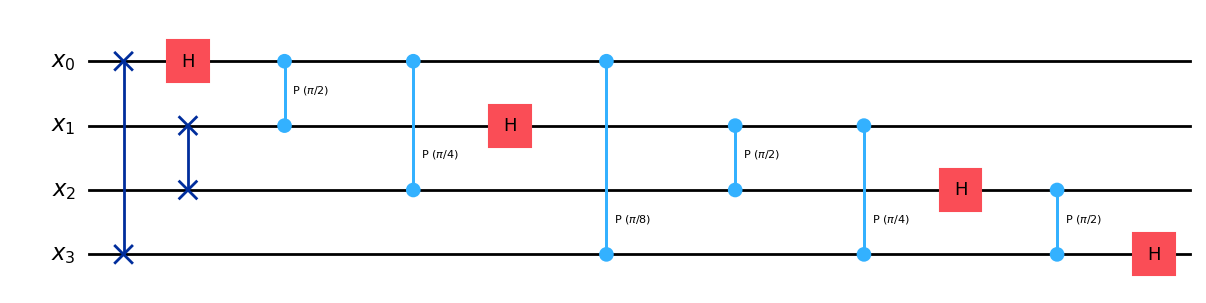

In [5]:
qft_circuit = quantum_fourier_transform(4)
qft_circuit.draw('mpl')

### Quantum Phase Estimation
